In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pylie import SO3

from ins_observer import ComplementaryINS, ObserverInfo
from utils import (
    get_from_df,
    get_noisy_state_from_df,
    get_true_state_from_df,
)
%matplotlib ipympl
%load_ext autoreload
%autoreload 2

# Import data

In [2]:
df = pd.read_csv(f"combined_data_30Hz_noisy.csv")
statesTru = [get_true_state_from_df(df, ii) for ii in range(len(df))]
noisyStates = [
    get_noisy_state_from_df(df, ii) for ii in range(len(df))
]
times = df["timestamp"].to_numpy()
with open("observers.pickle", "rb") as f:
    observer_list = pickle.load(f)
with open("ekf_results.pickle", "rb") as f:
    ekf_results = pickle.load(f)

# Trajectory

## Plotting Simulation

In [ ]:
plt.close("all")
fig, ax = plt.subplots()
ax.set_xlabel("X")
ax.set_ylabel("Y")
# ax.set_title("True and Noisy Odometry Trajectories")
ax.set_title("True, Observer Estimate, and EKF Estimate Trajectories")
ax.grid(True)
ax.axis("equal")

x = df["odom_pose_x"].to_numpy()
y = df["odom_pose_y"].to_numpy()
ax.annotate("Start", (x[0], y[0]), (-2.6, 1.8))
ax.annotate("End", (x[-1], y[-1]), (5, 5))
ax.plot(
    x,
    y,
    "g-",
    linewidth=3,
    label="Ground Truth",
)

# noisy_x = df["odom_pose_noisy_x"].to_numpy()
# noisy_y = df["odom_pose_noisy_y"].to_numpy()
# noisy_sc = ax.scatter(
#     noisy_x,
#     noisy_y,
#     label="Noisy Odometry",
#     color="orange",
#     alpha=0.5,
#     s=1,
# )
# ax.legend(markerscale=5.0)
# fig.savefig("paper_figures/true_noisy_trajs.png", dpi=500)

## Plotting Observers

In [ ]:
for ii, obs in enumerate(observer_list):
    vel_est = np.hstack([XEst[0:3, 3:4] for XEst in obs.states_est])
    pos_est = np.hstack([XEst[0:3, 4:5] for XEst in obs.states_est])
    lines = ax.plot(
        pos_est[0, :],
        pos_est[1, :],
        label=obs.name,
        color=obs.lc,
        alpha=0.4,
        linestyle=":",
    )
ax.legend(markerscale=5.0)
# plt.show()

## Plotting EKF

In [ ]:
from EKF_plots_modify_dhruv import quaternion_to_euler


def get_truth(gt_source, *candidate_names, fallback=None):
    """
    Try each candidate name in order; if found in gt_source (dict or DataFrame),
    return it as a numpy array. If none found, fall back to results[fallback].
    """
    for name in candidate_names:
        if isinstance(gt_source, dict) and name in gt_source:
            return np.asarray(gt_source[name])
        if hasattr(gt_source, "__contains__") and name in gt_source:
            return np.asarray(gt_source[name])
    if fallback is not None:
        return np.asarray(ekf_results[fallback])
    raise KeyError(
        f"None of {candidate_names} found in ground_truth and no fallback provided."
    )


est_x = np.asarray(ekf_results["est_x"])
est_y = np.asarray(ekf_results["est_y"])
est_roll = np.asarray(ekf_results["est_roll"])
est_pitch = np.asarray(ekf_results["est_pitch"])
est_yaw = np.asarray(ekf_results["est_yaw"])

ax.plot(
    est_x,
    est_y,
    linestyle="--",
    color="c",
    alpha=0.4,
    label="EKF",
)
ax.legend(markerscale=5.0)
plt.show()
# fig.savefig("paper_figures/true_ekf_observer_trajs.png", dpi=500)

# Error Statistics

## Observer Error

In [ ]:
plt.close("all")

fig, ax = plt.subplots(3, 1, layout="constrained")
for obs in observer_list:
    states_est = obs.states_est
    states_aux = obs.states_aux
    XCopy = [
        (XTru.copy(), XEst.copy())
        for XTru, XEst in zip(statesTru, states_est)
    ]
    for ii, (xtru, xest) in enumerate(XCopy):

        def modify_state(state):
            # Setting roll and pitch to 0 because we are in a flat space
            xtru_mod = state.copy()
            xtru_euler = SO3.from_matrix(state[0:3, 0:3]).as_euler()
            xtru_euler[0:2] = 0
            xtru_mod[0:3, 0:3] = SO3.from_euler(
                xtru_euler
            ).as_matrix()
            # Setting Z velocity, position to 0
            xtru_mod[2, 3:5] = 0
            return xtru_mod

        xtru_mod = modify_state(xtru)
        xest_mod = modify_state(xest)
        XCopy[ii] = (xtru_mod, xest_mod)

    att_error = np.array(
        [
            np.linalg.norm(
                SO3.log(
                    SO3.from_matrix(XTru[0:3, 0:3] @ XEst[0:3, 0:3].T)
                )
            )
            * 180.0
            / np.pi
            for XTru, XEst in XCopy
        ]
    )
    ax[0].plot(
        times,
        att_error,
        linestyle=obs.ls,
        color=obs.lc,
        label=obs.name,
        alpha=0.5,
    )

    vel_error = np.array(
        [
            np.linalg.norm(XTru[0:3, 3:4] - XEst[0:3, 3:4])
            for XTru, XEst in XCopy
        ]
    )
    print(f"{np.mean(vel_error)=}")
    ax[1].plot(
        times,
        vel_error,
        linestyle=obs.ls,
        color=obs.lc,
        label=obs.name,
        alpha=0.5,
    )

    pos_error = np.array(
        [
            np.linalg.norm(XTru[0:3, 4:5] - XEst[0:3, 4:5])
            for XTru, XEst in XCopy
        ]
    )
    ax[2].plot(
        times,
        pos_error,
        linestyle=obs.ls,
        color=obs.lc,
        label=obs.name,
        alpha=0.5,
    )

ax[0].set_ylabel("Yaw\nError (deg)")
ax[1].set_ylabel("Velocity\nError (m/s)")
ax[2].set_ylabel("Position\nError (m)")

for i in range(3):
    # ax[i].set_ylim([0, None])
    ax[i].set_xlim([times[0], times[-1]])
    ax[i].set_xticklabels([])
    ax[i].grid()

ax[-1].set_xlim([times[0], times[-1]])
ax[-1].set_xlabel("Time (s)")
ax[0].legend(ncol=2)
fig.suptitle("Observer Error Metrics")
plt.show()
fig.savefig("paper_figures/obs_error_metrics.png", dpi=500)

## EKF Error Stats

In [ ]:
times = times[1:]
ax[0].plot(
    times,
    ekf_results["error_yaw"],
    "g-",
    alpha=0.5,
    lw=1,
    label="EKF",
)
ax[0].legend(ncol=2)

vel_err = np.sqrt(
    (
        np.array(ekf_results["est_vx"])
        - np.array(ekf_results["true_vx"])
    )
    ** 2
    + (
        np.array(ekf_results["est_vy"])
        - np.array(ekf_results["true_vy"])
    )
    ** 2
)
ax[1].plot(
    times,
    vel_err,
    "g-",
    lw=1,
    label="EKF",
    alpha=0.5,
)
ax[1].set_ylabel("Velocity\nError (m/s)")
ax[1].grid(True, alpha=0.3)

ax[2].plot(
    times,
    ekf_results["error_position"],
    "g-",
    lw=1,
    alpha=0.5,
)
plt.suptitle("Observer vs EKF Error Metrics")
plt.show()
fig.savefig("paper_figures/observer_ekf_error_metrics.png", dpi=500)

# Estimation over Time

## Observer

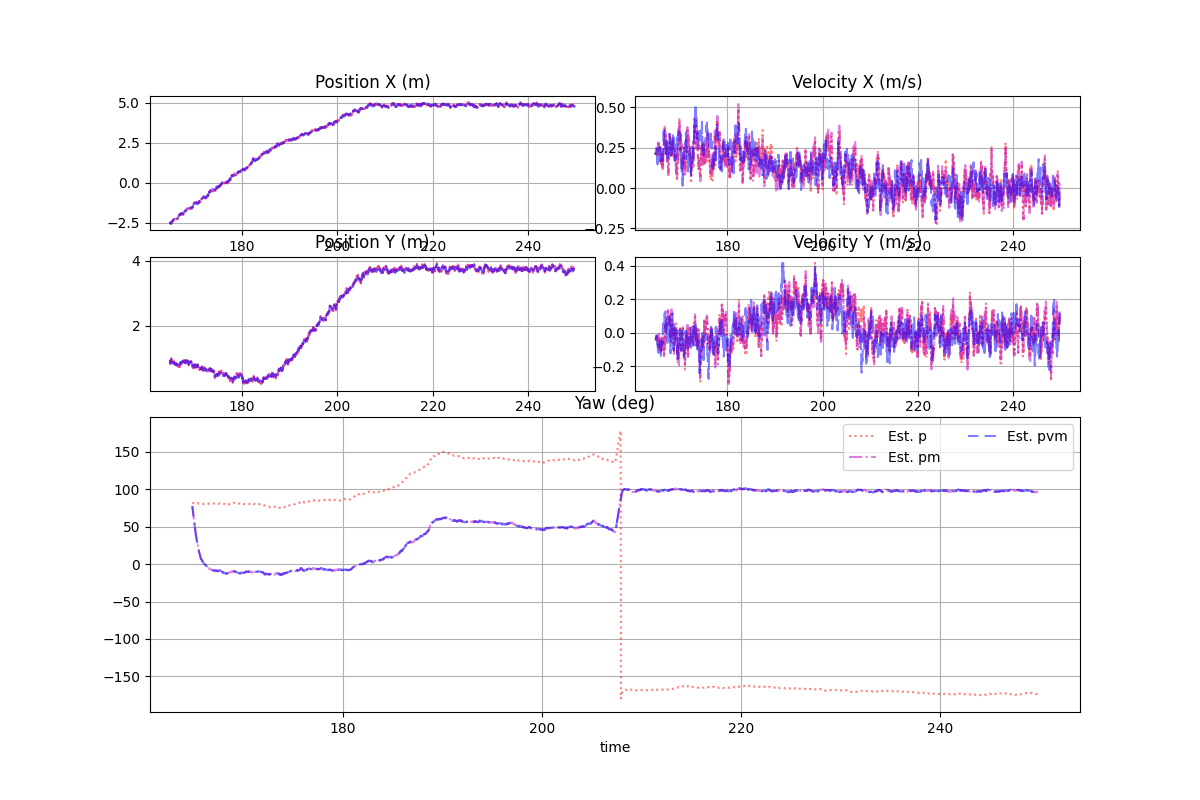

In [3]:
import matplotlib.gridspec as gridspec

plt.close("all")
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(4, 4, figure=fig)  # 3x3 grid

eul_tru = np.vstack(
    [SO3.from_matrix(XTru[0:3, 0:3]).as_euler() for XTru in statesTru]
).T
vel_tru = np.hstack([XTru[0:3, 3:4] for XTru in statesTru])
pos_tru = np.hstack([XTru[0:3, 4:5] for XTru in statesTru])

eul_noisy = np.vstack(
    [
        SO3.from_matrix(XNoisy[0:3, 0:3]).as_euler()
        for XNoisy in noisyStates
    ]
).T
vel_noisy = np.hstack([XNoisy[0:3, 3:4] for XNoisy in noisyStates])
pos_noisy = np.hstack([XNoisy[0:3, 4:5] for XNoisy in noisyStates])

posx_ax = fig.add_subplot(gs[0, 0:2])
posy_ax = fig.add_subplot(gs[1, 0:2])

posx_ax.set(xlabel="time", title="Position X (m)")
posy_ax.set(xlabel="time", title="Position Y (m)")

velx_ax = fig.add_subplot(gs[0, 2:])
vely_ax = fig.add_subplot(gs[1, 2:])
velx_ax.set(xlabel="time", title="Velocity X (m/s)")
vely_ax.set(xlabel="time", title="Velocity Y (m/s)")

yaw_ax = fig.add_subplot(gs[2:, :])
yaw_ax.set(xlabel="time", title="Yaw (deg)")

for obs in observer_list:
    eul_est = np.vstack(
        [
            SO3.from_matrix(XEst[0:3, 0:3]).as_euler()
            for XEst in obs.states_est
        ]
    ).T
    vel_est = np.hstack([XEst[0:3, 3:4] for XEst in obs.states_est])
    pos_est = np.hstack([XEst[0:3, 4:5] for XEst in obs.states_est])

    posx_ax.plot(
        times,
        pos_est[0, :],
        linestyle=obs.ls,
        color=obs.lc,
        label=obs.name,
        alpha=0.5,
    )
    posy_ax.plot(
        times,
        pos_est[1, :],
        linestyle=obs.ls,
        color=obs.lc,
        label=obs.name,
        alpha=0.5,
    )
    velx_ax.plot(
        times,
        vel_est[0, :],
        linestyle=obs.ls,
        color=obs.lc,
        label=obs.name,
        alpha=0.5,
    )
    vely_ax.plot(
        times,
        vel_est[1, :],
        linestyle=obs.ls,
        color=obs.lc,
        label=obs.name,
        alpha=0.5,
    )
    yaw_ax.plot(
        times,
        eul_est[2, :],
        linestyle=obs.ls,
        color=obs.lc,
        label=obs.name,
        alpha=0.5,
    )
est_axes = [posx_ax, posy_ax, velx_ax, vely_ax, yaw_ax]
for ii, ax in enumerate(est_axes):
    if ii == 4:
        ax.legend(ncol=2)
    ax.grid(True)
plt.show()
plt.tight_layout()

## True

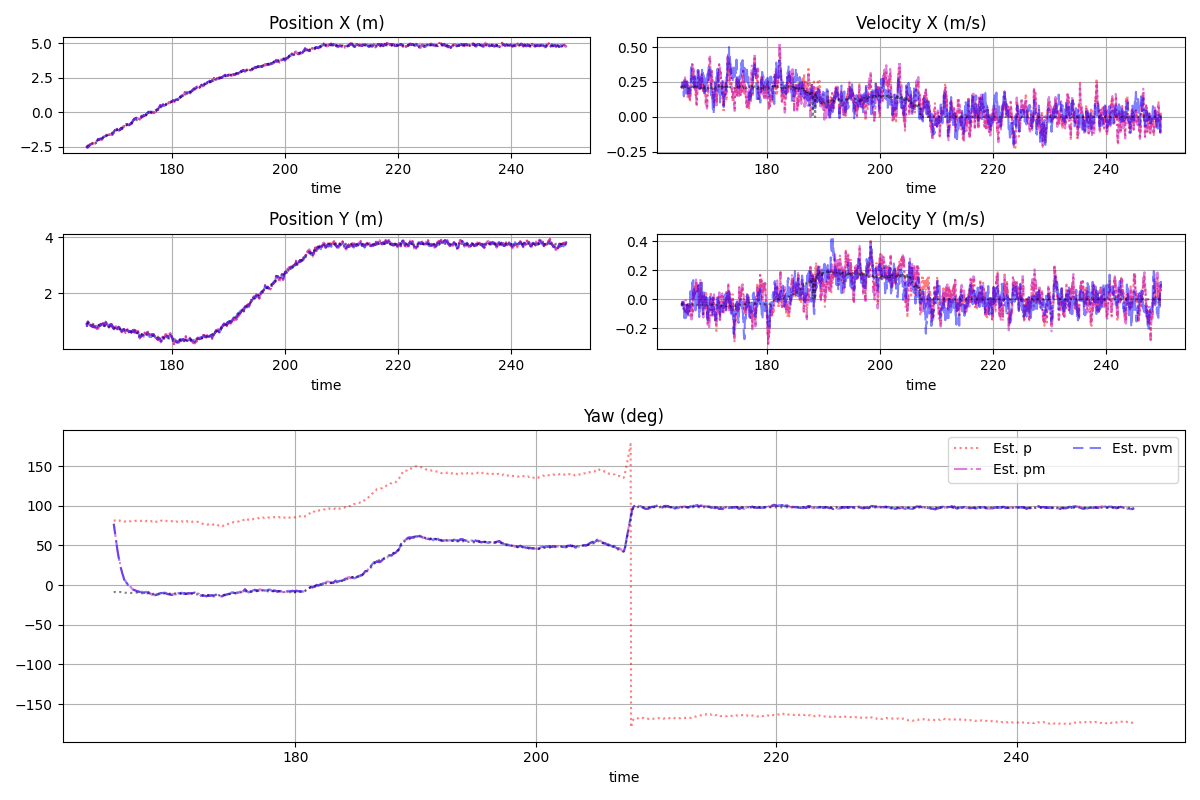

In [4]:
velx_ax.plot(times, vel_tru[0, :], "k:", label="True", alpha=0.5)
vely_ax.plot(times, vel_tru[1, :], "k:", label="True", alpha=0.5)

posx_ax.plot(times, pos_tru[0, :], "k:", label="True", alpha=0.5)
posy_ax.plot(times, pos_tru[1, :], "k:", label="True", alpha=0.5)
yaw_ax.plot(times, eul_tru[2, :], "k:", label="True", alpha=0.5)
plt.show()

## Noise

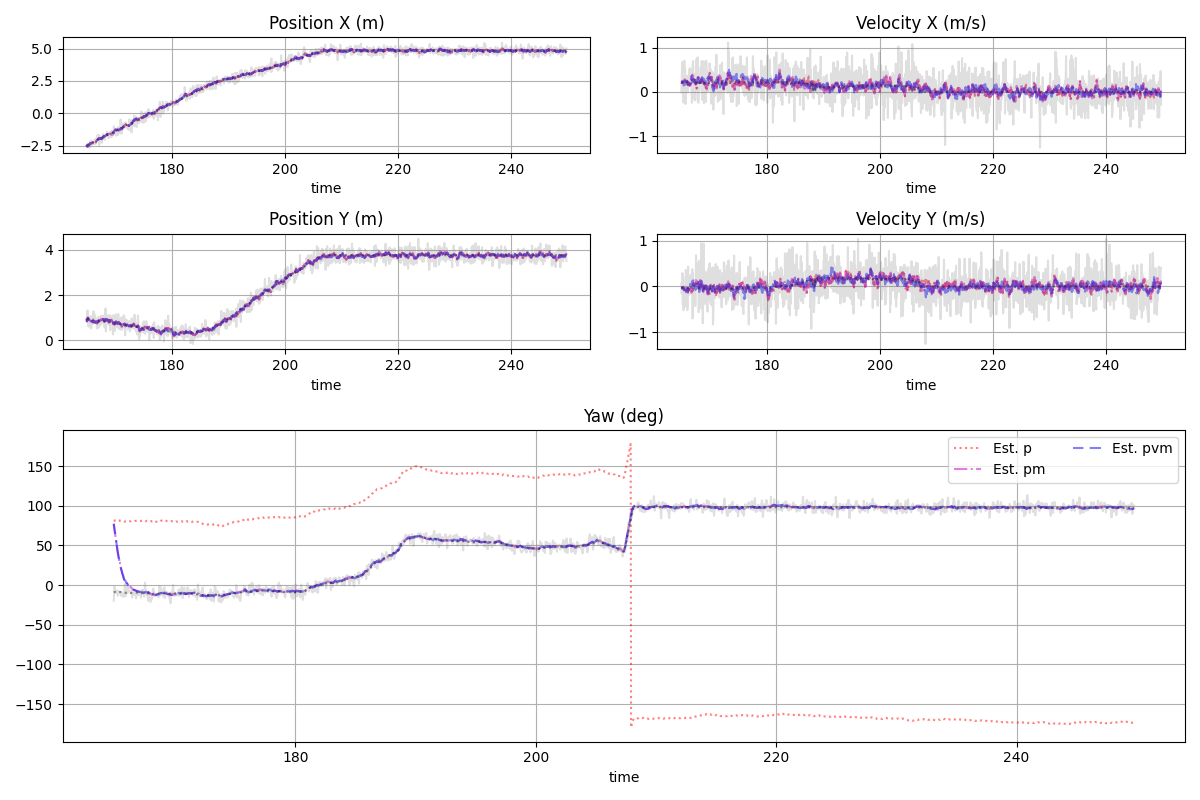

In [5]:
posx_ax.plot(
    times[::2],
    pos_noisy[0, :][::2],
    alpha=0.25,
    color="grey",
    label="noisy",
)
posy_ax.plot(
    times[::2],
    pos_noisy[1, :][::2],
    alpha=0.25,
    color="grey",
    label="noisy",
)

yaw_ax.plot(
    times[::2],
    eul_noisy[2, :][::2],
    alpha=0.25,
    color="grey",
    label="noisy",
)
velx_ax.plot(
    times[::2],
    vel_noisy[0, :][::2],
    alpha=0.25,
    color="grey",
    label="noisy",
)
vely_ax.plot(
    times[::2],
    vel_noisy[1, :][::2],
    alpha=0.25,
    color="grey",
    label="noisy",
)
plt.show()

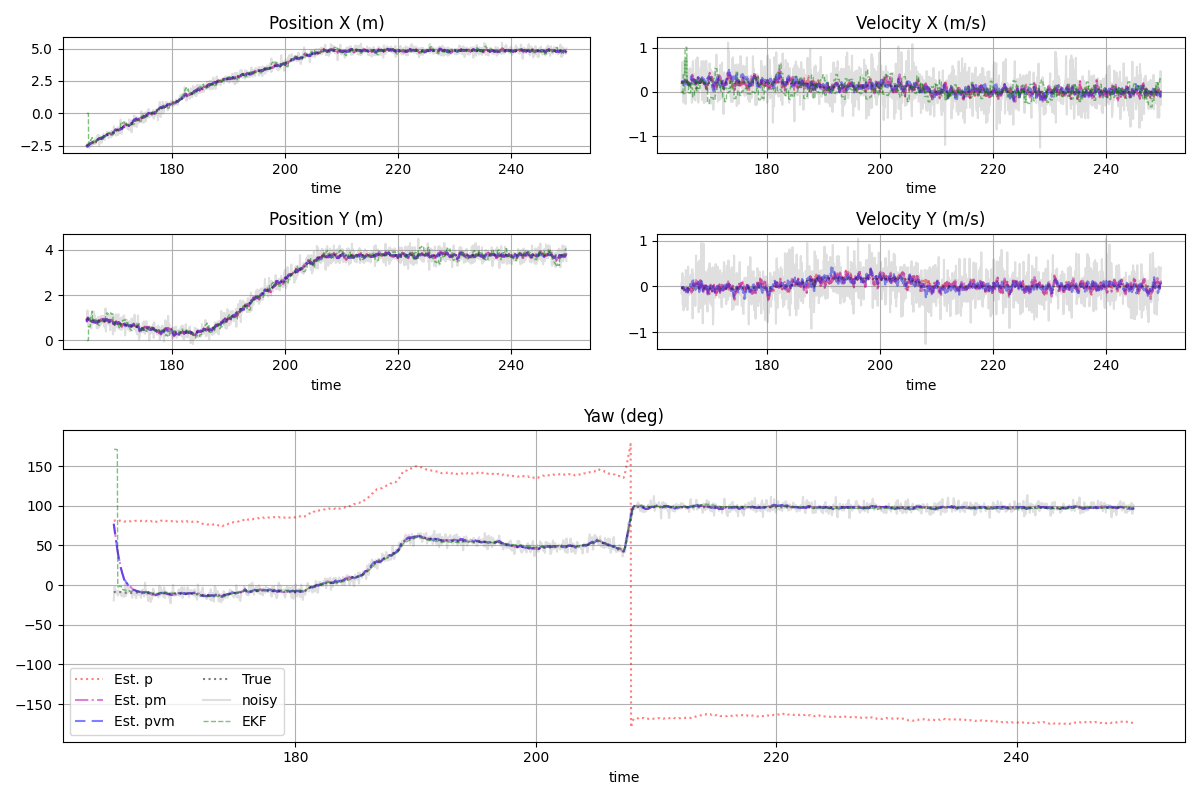

In [6]:
times = times[1:]
# yaw_ax.plot(times, ekf_results['true_yaw'], 'k-', lw=1.5)
yaw_ax.plot(
    times, ekf_results["est_yaw"], "g--", lw=1, label="EKF", alpha=0.5
)

# Velocity
# velx_ax.plot(times, ekf_results['true_vx'], 'k-', lw=1.5, label='True')
velx_ax.plot(times, ekf_results["est_vx"], "g--", lw=1, alpha=0.5)


# velx_ax.plot(times, ekf_results['true_vy'], 'k-', lw=1.5)
velx_ax.plot(times, ekf_results["est_vy"], "g--", lw=1, alpha=0.5)


# Position
# posx_ax.plot(times, ekf_results['true_x'], 'k-', lw=1.5, label='True')
posx_ax.plot(times, ekf_results["est_x"], "g--", lw=1, alpha=0.5)

# posy_ax.plot(times, ekf_results['true_y'], 'k-', lw=1.5)
posy_ax.plot(times, ekf_results["est_y"], "g--", lw=1, alpha=0.5)
yaw_ax.legend(ncol=2)
plt.show()

In [7]:
fig.savefig("paper_figures/observer_ekf_state_est.png", dpi=500)